<font color="darkred">Version: 4d    &emsp; &emsp; &emsp; &emsp; 2026-04-22</font>

<font face="Times"><font size="44">
# Analisis de Alquiler de bicicletas </font></font>
    
## Alejandro de Gárate

Bike Sharing Dataset from:
kaggle/akshmi25npathi/bike-sharing-dataset

## **Antecedentes**

Los sistemas de bicicletas compartidas representan la nueva generación de
alquileres de bicicletas tradicionales, donde todo el proceso, desde la
inscripción y el alquiler hasta la devolución, se ha automatizado.   

Mediante estos sistemas, el usuario puede alquilar fácilmente una bicicleta en
una ubicación determinada y devolverla en otra. Actualmente, existen más de
500 programas de bicicletas compartidas en todo el mundo, que suman más de
500.000 bicicletas. Hoy en día, existe un gran interés en estos sistemas
debido a su importante papel en la gestión del tráfico, el medio ambiente y
la salud.

<br>

Además de las interesantes aplicaciones prácticas de los sistemas de bicicletas
compartidas, las características de los datos que generan los hacen atractivos
para la investigación.    
A diferencia de otros servicios de transporte como el
autobús o el metro, la duración del viaje, la posición de salida y la de
llegada se registran explícitamente en estos sistemas.  
Esta característica convierte al sistema de bicicletas compartidas en una red
de sensores virtuales que puede utilizarse para monitorizar la movilidad en la
ciudad. Por lo tanto, se espera que la mayoría de los eventos importantes de la
ciudad puedan detectarse mediante el monitoreo de estos datos.

<font color="#008000"> *He elegido este dataset porque me resultó interesante y sale de lo habitual* </font>

## Dataset

El proceso de alquiler de bicicletas compartidas está altamente correlacionado
con las condiciones ambientales y estacionales.   
Por ejemplo, las condiciones climáticas, las precipitaciones, el día de la semana, la estación del año, la hora del día, etc., pueden afectar el comportamiento de los usuarios.

El conjunto de datos principal se relaciona con el registro histórico de dos
años correspondiente a los años 2011 y 2012 del sistema Capital Bikeshare,
Washington D.C., EE. UU., que está disponible públicamente en
http://capitalbikeshare.com/system-data.
Agregamos los datos por hora y por día, y luego extrajimos y añadimos la
información climática y estacional correspondiente.
La información climática se extrajo de http://www.freemeteo.com.

<font color="red">NOTA:</font> (del programador)

El dataset original fue sacado de kaggle, pero debido a que ya tenia columnas manipuladas, se prefirió llevarla a un estado más básico, para ser procesadas.

Por esta razón vamos a partir de otro dataset, pero básicamente con la misma información.

In [46]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

# Library of warnings would assist in ignoring warnings issued
import warnings
warnings.filterwarnings('ignore')

# libraries used to pre-process
from sklearn import preprocessing, linear_model
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

# libraries to evaluate performance
from sklearn import metrics
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, mean_absolute_error


In [47]:
# Leemos el archivo con los datos
df = pd.read_csv('hour_ini.csv', index_col=0)

##1. Recolección y Comprensión de los datos

In [48]:
# Obtenemos el nombre de las columnas y el tipo de dato
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17379 entries, 0 to 17378
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   rental_date  17379 non-null  object 
 1   hour         17379 non-null  int64  
 2   feriado      17379 non-null  int64  
 3   clima        17379 non-null  int64  
 4   casual_usr   17379 non-null  int64  
 5   regist_usr   17379 non-null  int64  
 6   count        17379 non-null  int64  
 7   temp         17379 non-null  float64
 8   termic_sens  17379 non-null  float64
 9   humidity     17379 non-null  float64
 10  windspeed    17379 non-null  float64
dtypes: float64(4), int64(6), object(1)
memory usage: 1.6+ MB


**Columnas:**
<pre>
 0   rental_date  fecha de alquiler   
 1   hour         hora de alquiler   
 2   feriado      si el dia es feriado (según Whashington - USA)      
 3   clima        tipo de clima por categoria   
 4   casual_usr   si el usuario es ocasional    
 5   regist_usr   si el usuario esta registrado  
 6   count        cantidad de bicicletas alquiladas en la hora   
 7   temp         temperatura en grados Celsius  
 8   termic_sens  sensacion termica en grados Celsius  
 9   humidity     humedad ambiente en porcentaje  
10   windspeed    velocidad del viento
</pre>

In [51]:
# Visualizamos los primeros registros para ver los datos
df.head()

,rental_date,hour,feriado,clima,casual_usr,regist_usr,count,temp,termic_sens,humidity,windspeed
0,2011-01-01,0,0,1,3,13,16,9.84,14.395,81.0,0.0
1,2011-01-01,1,0,1,8,32,40,9.02,13.635,80.0,0.0
2,2011-01-01,2,0,1,5,27,32,9.02,13.635,80.0,0.0
3,2011-01-01,3,0,1,3,10,13,9.84,14.395,75.0,0.0
4,2011-01-01,4,0,1,0,1,1,9.84,14.395,75.0,0.0


In [52]:
df.shape
print("Cantidad de registros: ", df.shape[0])
print("Cantidad de  columnas: ", df.shape[1])

Cantidad de registros:  17379
Cantidad de  columnas:  11


## 2. EDA y limpieza de datos

In [54]:
# Revisamos si hay datos nulos o faltantes
df.isnull().sum()

,0
rental_date,0
hour,0
feriado,0
clima,0
casual_usr,0
regist_usr,0
count,0
temp,0
termic_sens,0
humidity,0


No hay datos nulos, ni registros para descartar.

In [55]:
print("datos duplicados:", df.duplicated().sum() )

datos duplicados: 0


No hay datos registros duplicados

In [56]:
df.describe()

,hour,feriado,clima,casual_usr,regist_usr,count,temp,termic_sens,humidity,windspeed
count,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,11.546752,0.028770,1.425283,35.676218,153.786869,189.463088,20.376474,23.788755,62.722884,12.736540
std,6.914405,0.167165,0.639357,49.305030,151.357286,181.387599,7.894801,8.592511,19.292983,8.196795
min,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.820000,0.000000,0.000000,0.000000
25%,6.000000,0.000000,1.000000,4.000000,34.000000,40.000000,13.940000,16.665000,48.000000,7.001500
50%,12.000000,0.000000,1.000000,17.000000,115.000000,142.000000,20.500000,24.240000,63.000000,12.998000
75%,18.000000,0.000000,2.000000,48.000000,220.000000,281.000000,27.060000,31.060000,78.000000,16.997900
max,23.000000,1.000000,4.000000,367.000000,886.000000,977.000000,41.000000,50.000000,100.000000,56.996900


In [57]:
# Convertimos rental_date de object a datetime
df["rental_date"] = pd.to_datetime(df["rental_date"])

# extraemos el año a una columna nueva
df["year"] = df["rental_date"].dt.year

In [58]:
# Vemos que años estan presentes
print(f"Años presentes: {df["year"].unique()} ")

Años presentes: [2011 2012] 


In [59]:
# como vemos sólo hay dos años 2011 y 2012
# convertimos la columna en formato Binary 2011= 0, 2012= 1
df["year"] = df["year"] - 2011

In [60]:
# creamos una columna month/mes en base 1-12
df["month"] = df["rental_date"].dt.month

In [61]:
df.head(5)

,rental_date,hour,feriado,clima,casual_usr,regist_usr,count,temp,termic_sens,humidity,windspeed,year,month
0,2011-01-01,0,0,1,3,13,16,9.84,14.395,81.0,0.0,0,1
1,2011-01-01,1,0,1,8,32,40,9.02,13.635,80.0,0.0,0,1
2,2011-01-01,2,0,1,5,27,32,9.02,13.635,80.0,0.0,0,1
3,2011-01-01,3,0,1,3,10,13,9.84,14.395,75.0,0.0,0,1
4,2011-01-01,4,0,1,0,1,1,9.84,14.395,75.0,0.0,0,1


### Funciones auxiliares para trabajar

In [62]:
# DayOfWeek()
def DOW( nday):
    aDays =["Domingo","Lunes", "Martes", "Miercoles","Jueves","Viernes","Sabado"]
    return aDays[ nday]

# working days goes from 1-5. 0=Domingo, 6=Sabado (no laborable)
# Numeric DOW() 0=Domingo .. 6=Sabado
def NDOW( fecha):
    if type(fecha) == str:
       fecha = pd.to_datetime(fecha)
    # Move the assignment of ndia outside the if block
    ndia = int(fecha.strftime("%w"))
    return ndia

In [63]:
#  Estaciones en el Hemisferio Norte
season_list = ["","invierno","primavera", "verano", "otoño"]

def season( x):
    return season_list[x]

def get_season( fecha):
    ''' obtiene la estacion segun la fecha
    '''
    if type(fecha) == str:
        fecha = pd.to_datetime(fecha)

    dia = fecha.day
    mes = fecha.month

    if mes == 1 or mes == 2:
       nSeason = 1

    elif mes == 3:
       if dia < 21:
          nSeason = 1
       else:
          nSeason = 2
    elif mes == 4 or mes == 5:
        nSeason = 2

    elif mes == 6:
        if dia < 21:
           nSeason = 2
        else:
           nSeason = 3
    elif mes == 7 or mes == 8:
        nSeason = 3

    elif mes == 9:
        if dia < 21:
           nSeason = 3
        else:
           nSeason = 4
    elif mes == 10 or mes == 11:
        nSeason = 4

    elif mes == 12:
        if dia < 21:
           nSeason = 4
        else:
           nSeason = 1
    return nSeason

In [64]:
# CLIMA
clima_list = ["",
	"1. Claro / pocas nubes / nublado parcialmente",
	"2. Niebla + Nublado / Niebla + Nublado Parcialmente / Niebla",
	"3. Nevada Ligera / Llovizna + Tormenta + Nubes Dispersas / Lluvia ligera + Nubes Dispersas",
	"4. Lluvia Intensa + Granizo / Tormenta + Niebla / Nieve + Niebla"
]

## 3. Preprocesamiento y Preparación de los datos

Vamos a proceder a crear distintas columnas con el fin de poder hacer un analisis más granular y detallado<br> con respecto a los días de alquiler.

* Que día de la semana se hizo el alquiler ?   
  Creamos una columna con esa información => weekday

* El alquiler se hizo en un día laborable ?   
  Creamos una columna con esa información => workingday  

* El alquiler se hizo en un día feriado   
  Ya posee una columna con esa información => feriado

* El alquiler se hizo en un fin de semana ?    
  Creamos una columna con esa información => weekend
  (aunque en realidad esta implicito en !workingday)

* Los alquileres aumentan con el buen tiempo y por tanto de la estación del año
  en que se encuentre.   
  Creamos una columna con esa información => season


In [65]:
# Creamos una columna con el nro dia de semana Dom =0 .. Sab =6
df["weekday"] = df["rental_date"].apply(NDOW)


In [66]:
# Creamos una columna con esa información => workingday
# Si feriado es 1, workingday debe ser 0. De lo contrario,
# se calcula en función del día de la semana.
df["workingday"] = np.where(df["feriado"] == 1, 0,
                            df["weekday"].apply(lambda x: 1 if (x > 0 and x <6) else 0))

In [67]:
# Creamos una columna con esa información => season
df["season"] = df["rental_date"].apply(get_season)

Reordenamos las columnas

In [68]:
# Reordenamos las columnas
df = df[["rental_date", "hour", "year", "month", "weekday", "workingday", "feriado",
        "season", "temp", "termic_sens", "humidity", "windspeed", "clima",
        "casual_usr",	"regist_usr",	"count"]]


In [69]:
df.head()

,rental_date,hour,year,month,weekday,workingday,feriado,season,temp,termic_sens,humidity,windspeed,clima,casual_usr,regist_usr,count
0,2011-01-01,0,0,1,6,0,0,1,9.84,14.395,81.0,0.0,1,3,13,16
1,2011-01-01,1,0,1,6,0,0,1,9.02,13.635,80.0,0.0,1,8,32,40
2,2011-01-01,2,0,1,6,0,0,1,9.02,13.635,80.0,0.0,1,5,27,32
3,2011-01-01,3,0,1,6,0,0,1,9.84,14.395,75.0,0.0,1,3,10,13
4,2011-01-01,4,0,1,6,0,0,1,9.84,14.395,75.0,0.0,1,0,1,1


Normalizamos algunas variables numéricas, preparandolas para el modelo:  
El nombre de los campos va a estar precedido por "<font color="darkred">N</font>" indicando que estan normalizados

In [70]:
df['humidity'].describe()

,humidity
count,17379.000000
mean,62.722884
std,19.292983
min,0.000000
25%,48.000000
50%,63.000000
75%,78.000000
max,100.000000


In [71]:
# Se normaliza la humedad
# Los valores se dividen por 100 (max) porque tenemos un min =0
df['Nhumidity'] = df['humidity'] / 100

In [72]:
df['windspeed'].describe()

,windspeed
count,17379.000000
mean,12.736540
std,8.196795
min,0.000000
25%,7.001500
50%,12.998000
75%,16.997900
max,56.996900


In [73]:
# Se normaliza el viento
# Los valores se dividen por 57 (max) porque tenemos un min =0
df['Nwindspeed'] = df['windspeed'] / 57

In [74]:
df["temp"].describe()

,temp
count,17379.000000
mean,20.376474
std,7.894801
min,0.820000
25%,13.940000
50%,20.500000
75%,27.060000
max,41.000000


In [75]:
# Se normaliza la temperatura
# Creamos el escalador y aplicamos Min-Max Scaling para normalizar a un rango de [0, 1]
#scaler_temp = MinMaxScaler()
#df['Ntemp'] = scaler_temp.fit_transform(df[['temp']])

# para ahorrar tiempo. En realidad hay que hacer MinMaxScaler()
df['Ntemp'] = df["temp"] / 41

In [76]:
df["termic_sens"].describe()

,termic_sens
count,17379.000000
mean,23.788755
std,8.592511
min,0.000000
25%,16.665000
50%,24.240000
75%,31.060000
max,50.000000


In [77]:
# Se normaliza la sens termica dividiendo / 50
# Los valores se dividen por 50 (max) porque tenemos un min =0
df["Ntermic_sens"] = df["termic_sens"] / 50

In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17379 entries, 0 to 17378
Data columns (total 20 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   rental_date   17379 non-null  datetime64[ns]
 1   hour          17379 non-null  int64         
 2   year          17379 non-null  int32         
 3   month         17379 non-null  int32         
 4   weekday       17379 non-null  int64         
 5   workingday    17379 non-null  int64         
 6   feriado       17379 non-null  int64         
 7   season        17379 non-null  int64         
 8   temp          17379 non-null  float64       
 9   termic_sens   17379 non-null  float64       
 10  humidity      17379 non-null  float64       
 11  windspeed     17379 non-null  float64       
 12  clima         17379 non-null  int64         
 13  casual_usr    17379 non-null  int64         
 14  regist_usr    17379 non-null  int64         
 15  count         17379 non-null  int64      

In [79]:
df.head()

,rental_date,hour,year,month,weekday,workingday,feriado,season,temp,termic_sens,humidity,windspeed,clima,casual_usr,regist_usr,count,Nhumidity,Nwindspeed,Ntemp,Ntermic_sens
0,2011-01-01,0,0,1,6,0,0,1,9.84,14.395,81.0,0.0,1,3,13,16,0.81,0.0,0.24,0.2879
1,2011-01-01,1,0,1,6,0,0,1,9.02,13.635,80.0,0.0,1,8,32,40,0.80,0.0,0.22,0.2727
2,2011-01-01,2,0,1,6,0,0,1,9.02,13.635,80.0,0.0,1,5,27,32,0.80,0.0,0.22,0.2727
3,2011-01-01,3,0,1,6,0,0,1,9.84,14.395,75.0,0.0,1,3,10,13,0.75,0.0,0.24,0.2879
4,2011-01-01,4,0,1,6,0,0,1,9.84,14.395,75.0,0.0,1,0,1,1,0.75,0.0,0.24,0.2879


## GRAFICOS

In [85]:
# cantidad de registros de 2011
reg_2011 = df[df["year"] == 0].shape[0]
print(f"reg 2011: {reg_2011} registros")

reg 2011: 8645 


In [88]:
# cantidad de registros de 2012
reg_2012 = df[df["year"] == 1].shape[0]
print(f"reg 2012: {reg_2012} registros")

print(f"Total reg 2011-2012: {reg_2011 + reg_2012} registros" )

reg 2012: 8734 registros
Total reg 2011-12: 17379 registros


In [ ]:
# agregado por mes y año
total_mes = df.groupby(['year', 'month'])['count'].sum().reset_index()
total_mes['year'] = total_mes['year'].map({0: 2011, 1: 2012})

# agregado total por año
total_year = df.groupby(['year'])['count'].sum().reset_index()
total_year['year'] = total_year['year'].map({0: 2011, 1: 2012})

In [ ]:
total_mes

,year,month,count
0,2011,1,38189
1,2011,2,48215
2,2011,3,64045
3,2011,4,94870
4,2011,5,135821
5,2011,6,143512
6,2011,7,141341
7,2011,8,136691
8,2011,9,127418
9,2011,10,123511


In [ ]:
display(total_year)

# Obtenemos los totales por año
y2011 = total_year.iloc[0,1]
y2012 = total_year.iloc[1,1]


,year,count
0,2011,1243103
1,2012,2049576


In [ ]:
delta = (y2012 *100 /y2011) -100
print(f"Incremento en el alquiler: { delta:.02f} % más")

Incremento en el alquiler: 64.88 % más


In [ ]:
# contar los reg

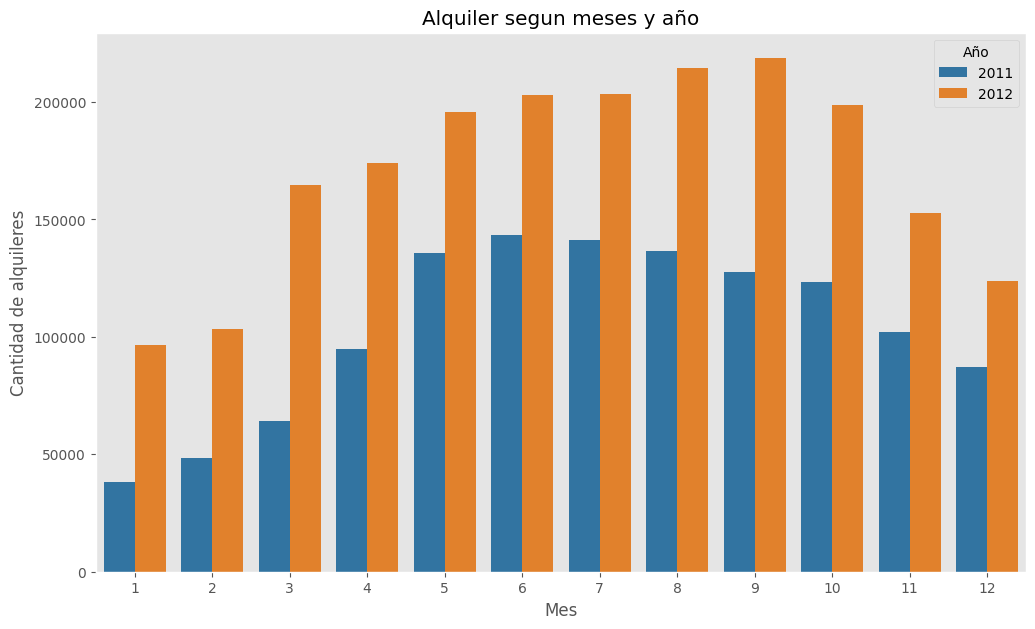

In [ ]:
plt.figure(figsize=(12, 7))
sns.barplot(x='month', y='count', hue='year', data=total_mes, palette='tab10')
plt.title('Alquiler segun meses y año')
plt.xlabel('Mes')
plt.ylabel('Cantidad de alquileres')
plt.xticks(rotation=0)
plt.legend(title='Año')
plt.grid(axis='y')
plt.show()

In [ ]:
# agregado por season y año
total_season = df.groupby(['year', 'season'])['count'].sum().reset_index()
total_season['year'] = total_season['year'].map({0: 2011, 1: 2012})

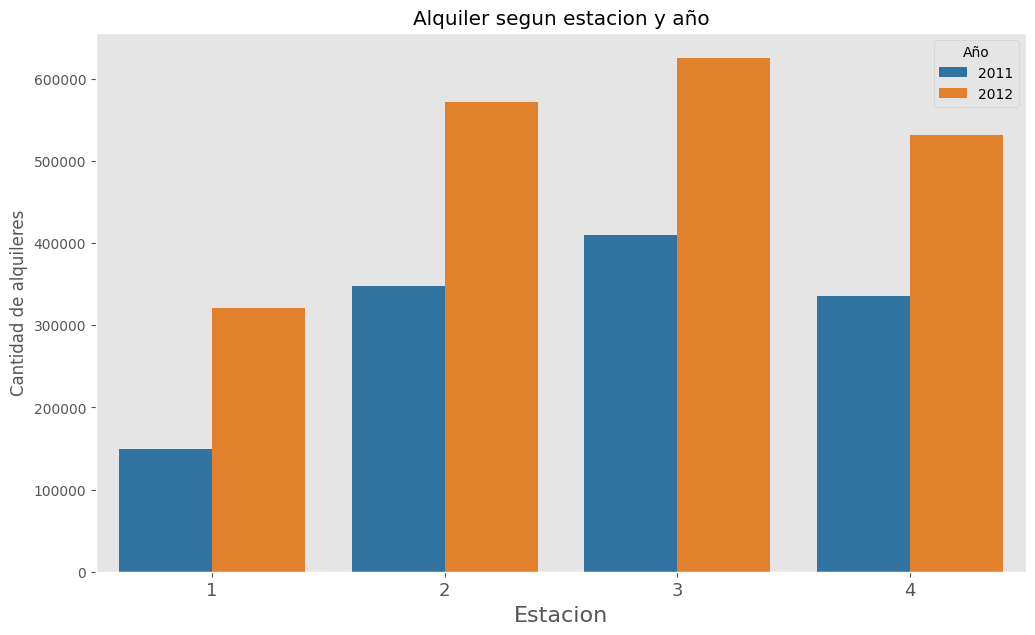

In [ ]:
plt.figure(figsize=(12, 7))
sns.barplot(x='season', y='count', hue='year', data=total_season, palette='tab10')
plt.title('Alquiler segun estacion y año')
plt.xlabel('Estacion', size="16")
plt.ylabel('Cantidad de alquileres')
plt.xticks(rotation=0, size=13)
plt.legend(title='Año')
plt.grid(axis='y')
plt.show()

In [ ]:
# agregado por hora, season y año
mean_hour = df.groupby(['year', 'season', 'hour'])['count'].mean().reset_index()
mean_hour['year'] = mean_hour['year'].map({0: 2011, 1: 2012})


In [ ]:
# Redondeamos el valor de 'count' en mean_hour
mean_hour['count'] = mean_hour['count'].apply(lambda x: round(x))
mean_hour

,year,season,hour,count
0,2011,1,0,19
1,2011,1,1,12
2,2011,1,2,8
3,2011,1,3,5
4,2011,1,4,2
...,...,...,...,...
187,2012,4,19,366
188,2012,4,20,261
189,2012,4,21,195
190,2012,4,22,148


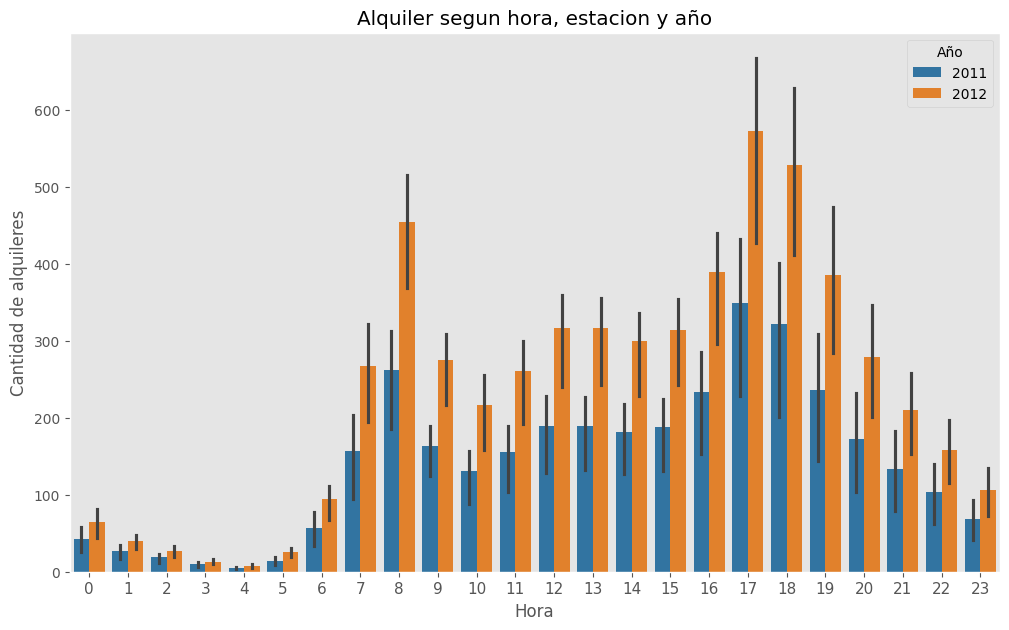

In [ ]:
plt.figure(figsize=(12, 7))
sns.barplot(x='hour', y='count', hue='year', data=mean_hour, palette='tab10')
plt.title('Alquiler segun hora, estacion y año')
plt.xlabel('Hora', size="12")
plt.ylabel('Cantidad de alquileres')
plt.xticks(rotation=0, size=11)
plt.legend(title='Año')
plt.grid(axis='y')
plt.show()

<font color="white">que significa la barra superior en cada hora del grafico<br>
La barra superior en cada hora del gráfico se conoce como barra de error. Dado que el gráfico muestra el promedio de alquileres por hora, esta barra de error representa el intervalo de confianza de la media. <br><br>
En este caso, una barra más larga indica una mayor variabilidad en la cantidad de alquileres de bicicletas para esa hora en particular, lo que significa que el número de alquileres puede fluctuar mucho alrededor del promedio. Una barra más corta sugiere que los alquileres son más consistentes con el promedio para esa hora. Por defecto, Seaborn usa un intervalo de confianza del 95%. </font>

## Matriz de Correlación

Vamos a generar una matriz de correlación para entender las relaciones entre las variables numéricas del dataset.    
Esto nos ayudará a identificar qué variables están fuertemente relacionadas entre sí o con la variable objetivo <font color="red">`count`</font>.

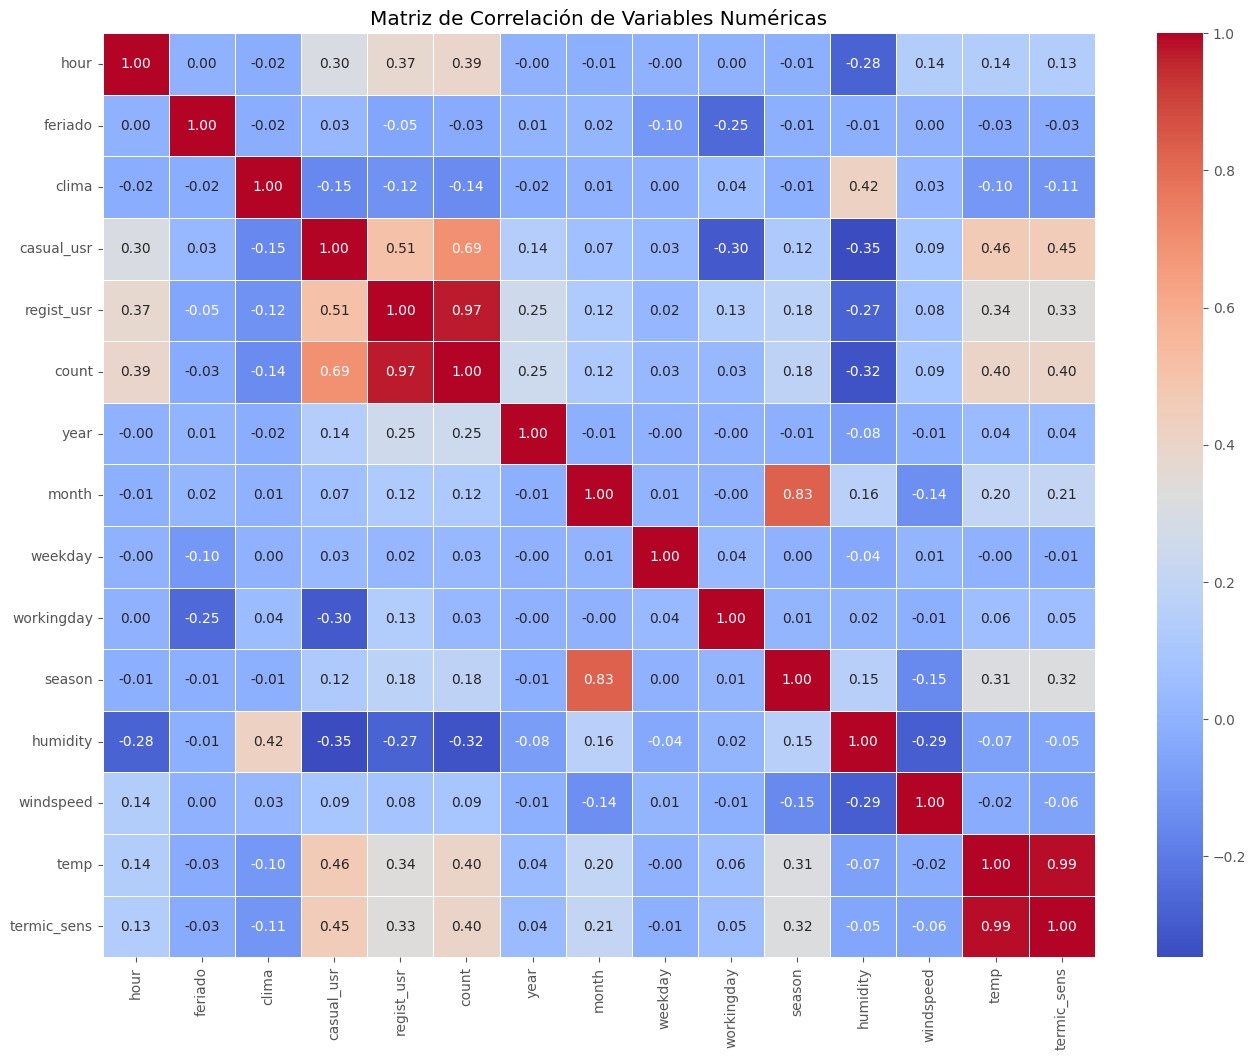

In [ ]:
#import seaborn as sns
#import matplotlib.pyplot as plt

# Seleccionamos las columnas numéricas relevantes para la matriz de correlación
# Incluimos tanto las originales como las normalizadas para ver su relación
numerical_cols = [
    'hour', 'feriado', 'clima', 'casual_usr', 'regist_usr', 'count',
    'year', 'month', 'weekday', 'workingday', 'season',
    'humidity', 'windspeed', 'temp', 'termic_sens'
]

correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

Como podemos ver en el mapa de calor:   
* usarios registrados tienen correlacion alta con la cantidad de alquileres (0.97)
* usuarios casuales tienen correlacion media con la cantidad de alquileres (0.69)

Ahora debemos ver cómo afectan el clima (humedad / lluvia / nieve, temp, viento), consecuencia de season (estación del año) y la hora del día en los alquileres.

In [ ]:
c4 = df[df["clima"] == 4]
print(f"Cantidad de alquileres con clima = 4: {c4.shape[0]}")
c4

Cantidad de alquileres con clima = 4: 3


,rental_date,hour,year,month,weekday,workingday,feriado,season,temp,termic_sens,humidity,windspeed,clima,casual_usr,regist_usr,count,Nwindspeed,Ntemp,Ntermic_sens
585,2011-01-26,16,0,1,3,1,0,1,9.02,9.850,93.0,22.0028,4,1,35,36,0.386014,0.22,0.1970
8854,2012-01-09,18,1,1,1,1,0,1,8.20,11.365,86.0,6.0032,4,6,158,164,0.105319,0.20,0.2273
9123,2012-01-21,1,1,1,6,0,0,1,5.74,6.820,86.0,12.9980,4,1,22,23,0.228035,0.14,0.1364



the column hour has:  hour
16    730
17    730
15    729
14    729
13    729
12    728
18    728
19    728
20    728
21    728
22    728
23    728
8     727
9     727
10    727
7     727
11    727
0     726
6     725
1     724
5     717
2     715
4     697
3     697
Name: count, dtype: int64

the column feriado has:  feriado
0    16879
1      500
Name: count, dtype: int64

the column clima has:  clima
1    11413
2     4544
3     1419
4        3
Name: count, dtype: int64

the column year has:  year
1    8734
0    8645
Name: count, dtype: int64

the column month has:  month
7     1488
5     1488
12    1483
8     1475
3     1473
10    1451
6     1440
4     1437
9     1437
11    1437
1     1429
2     1341
Name: count, dtype: int64


<Figure size 500x500 with 0 Axes>

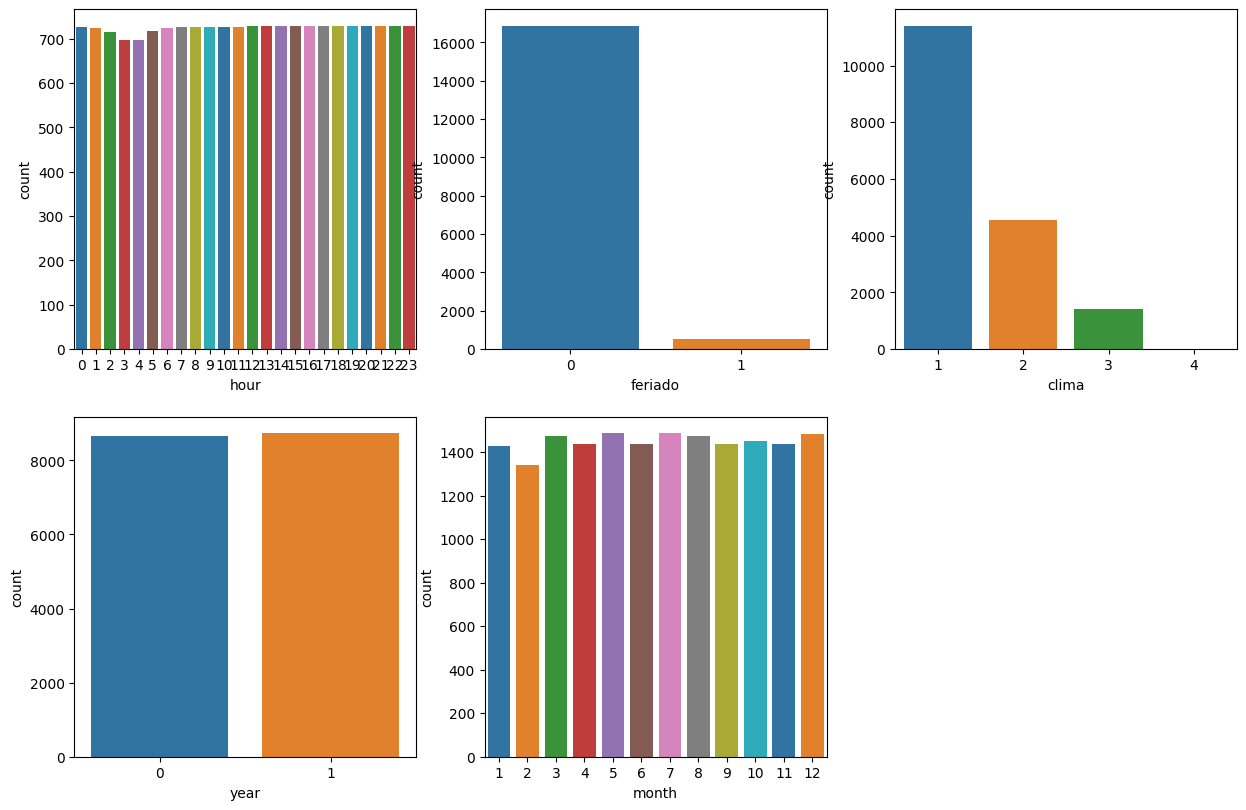

In [ ]:
# Contar valores para cada columna que tiene valores contables y graficar esta cantidad
#plt.style.use('ggplot')

plt.figure(figsize=(5,5))
counter=1
plt.figure(figsize=(15,15))

for col in df.columns:
    if col in ['season','year','month', 'hour','feriado', 'clima','weekday','workingday']:

        print(f"\nthe column {col} has: ",df[col].value_counts())
        plt.subplot(3,3,counter)
        sns.countplot(x=col,data=df, palette='tab10' )
        counter+=1
plt.show()


De los graficos de arriba podemos extraer conclusiones:   
<font color="green">Se renta mayor cantidad: </font>  
* si el dia es laborable (workingday=1)
* si el dia NO es feriado (feriado=0)
* Si hay buenas condiciones meteorologicas(clima=1)  

<font color="darkred">Se renta menor cantidad: </font>
* Disminuye un poco en las primeras horas de la madrugada
* Disminuye un poco en el mes de Febrero (invierno)

Donde el CLIMA es:
1. Cielo claro o parcialmente nublado   
2. Con niebla / nublado
3. Con lluvia ligera / nieve ligera
4. Con Lluvia Intensa / Granizo / Tormenta + Niebla / Nieve + Niebla   

**Hay sólo 3 alquileres cuando el clima == 4**

In [ ]:
# Dividimos datos en numerical y categorical features

categorical_features = df[["month", "season", "feriado", "clima"]].astype("category").copy()

#numerical_features = df.select_dtypes(exclude = 'object')


In [ ]:
categorical_features.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17379 entries, 0 to 17378
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   month    17379 non-null  category
 1   season   17379 non-null  category
 2   feriado  17379 non-null  category
 3   clima    17379 non-null  category
dtypes: category(4)
memory usage: 204.5 KB


In [ ]:
categorical_features.head()

,month,season,feriado,clima
0,1,1,0,1
1,1,1,0,1
2,1,1,0,1
3,1,1,0,1
4,1,1,0,1


In [ ]:
numerical_features.head(2)

,rental_date,hour,year,month,weekday,workingday,feriado,season,temp,termic_sens,humidity,windspeed,clima,casual_usr,regist_usr,count,Nhumidity,Nwindspeed,Ntemp,Ntermic_sens
0,2011-01-01,0,0,1,6,0,0,1,9.84,14.395,81.0,0.0,1,3,13,16,0.81,0.0,0.24,0.2879
1,2011-01-01,1,0,1,6,0,0,1,9.02,13.635,80.0,0.0,1,8,32,40,0.80,0.0,0.22,0.2727


ValueError: num must be an integer with 1 <= num <= 9, not 10

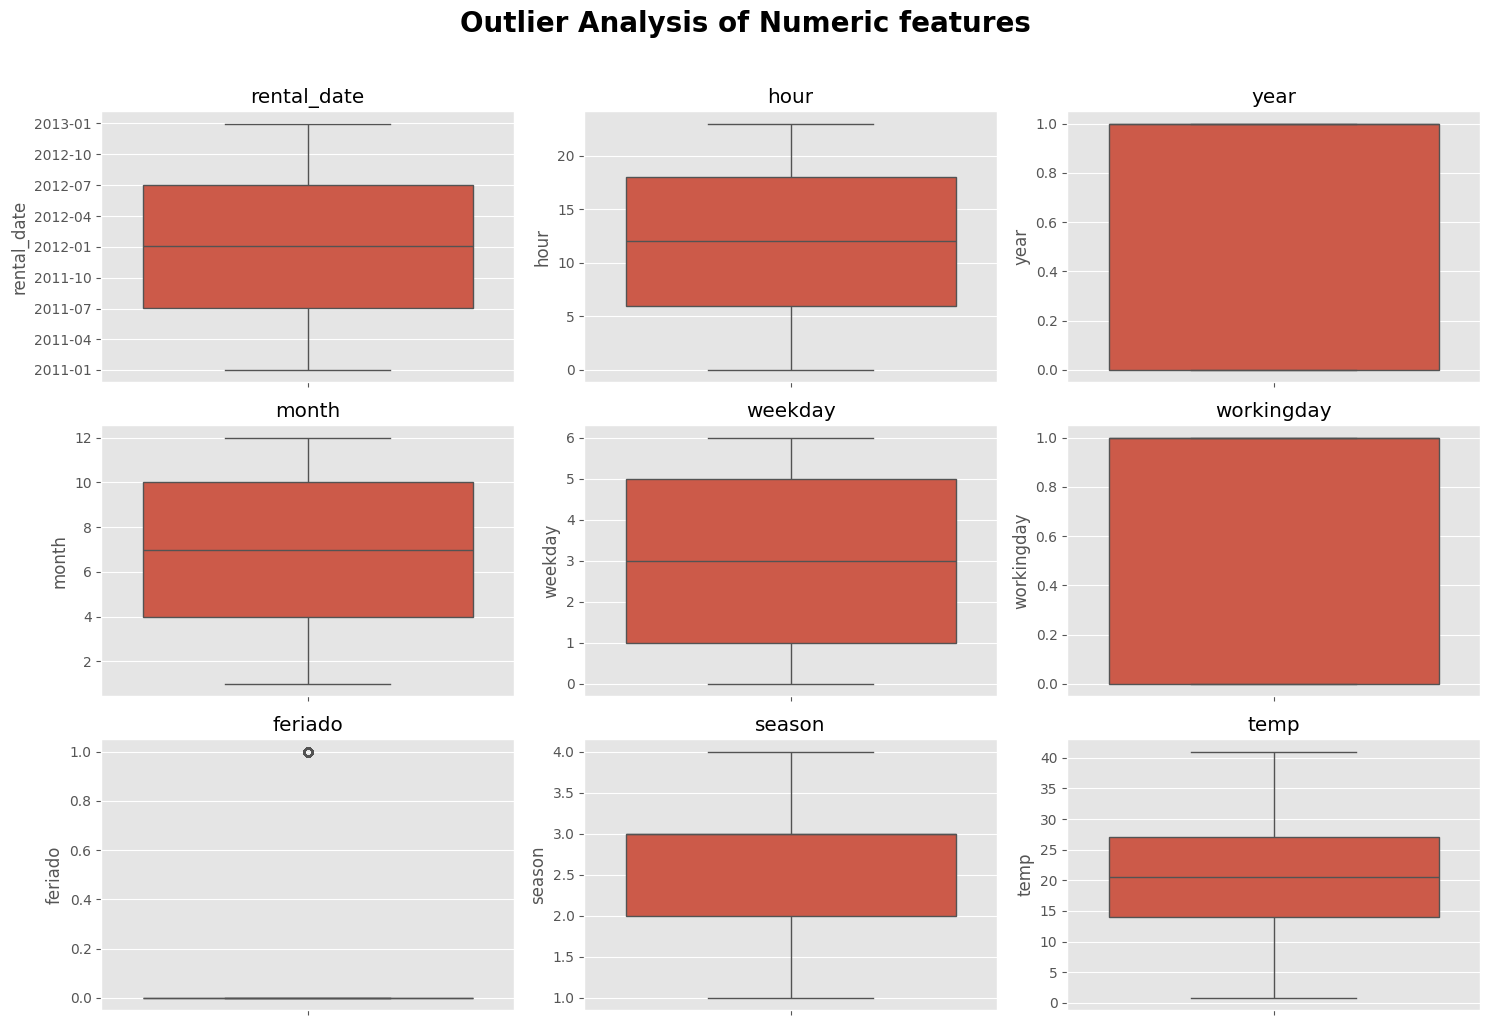

In [ ]:
# figsize
plt.figure(figsize = (15,10))

# title
plt.suptitle('Outlier Analysis of Numeric features', fontsize = 20, fontweight='bold', y=1.02)

for i, col in enumerate(numerical_features):
  # subplots 3 rows, 3 columns
  plt.subplot(3,3, i+1)

  # boxplots
  sns.boxplot(numerical_features[col])

  plt.title(col)
  plt.tight_layout()

month
0        NaN
1        NaN
2        NaN
3        NaN
4        NaN
        ... 
17374    NaN
17375    NaN
17376    NaN
17377    NaN
17378    NaN
Name: month_labels, Length: 17379, dtype: object


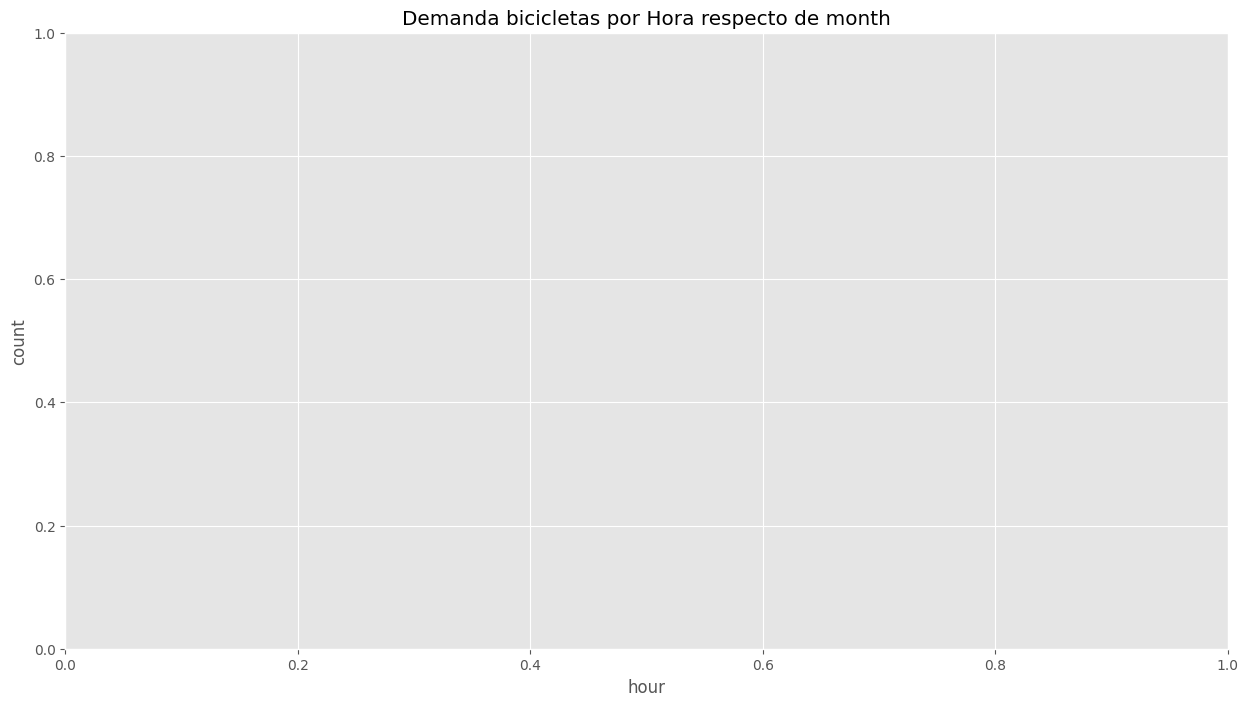

season


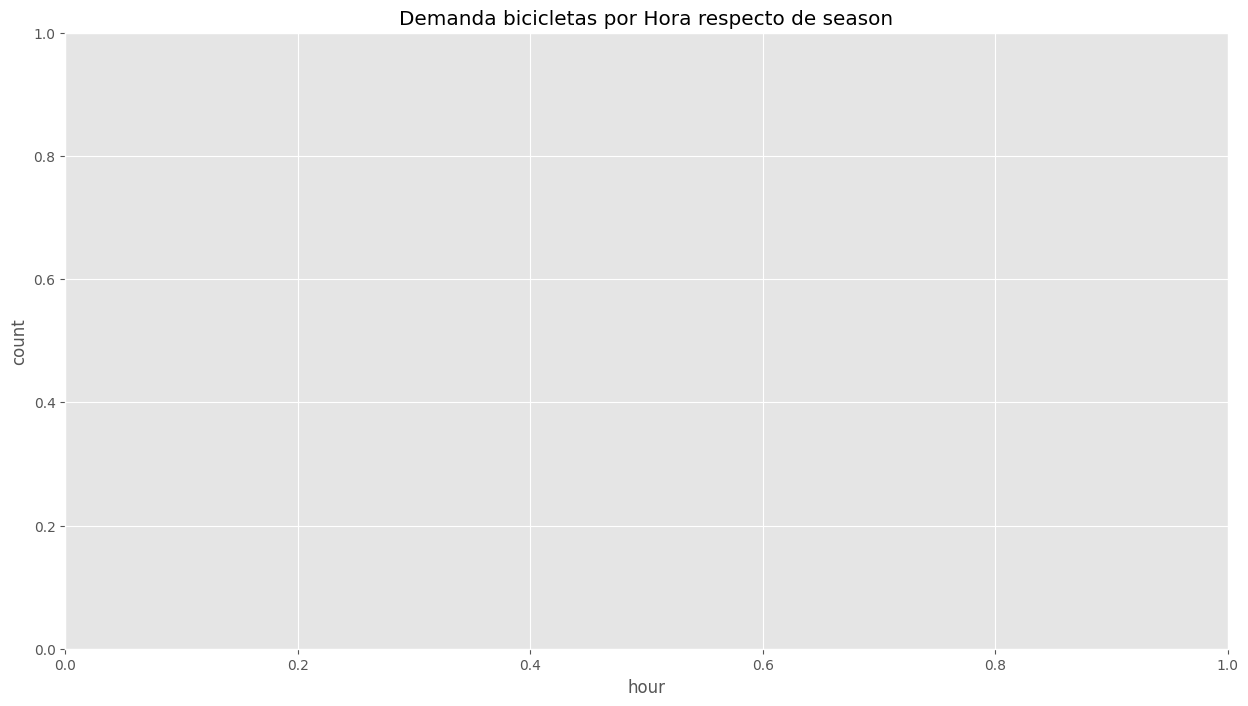

feriado


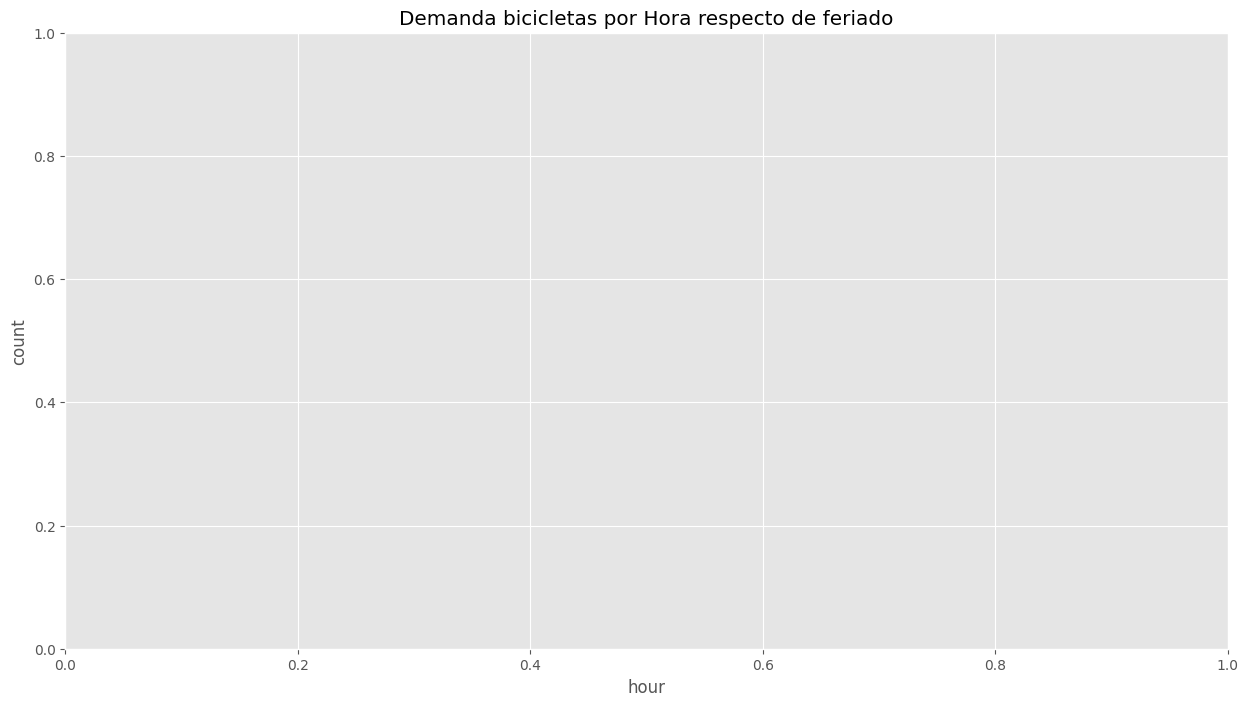

clima


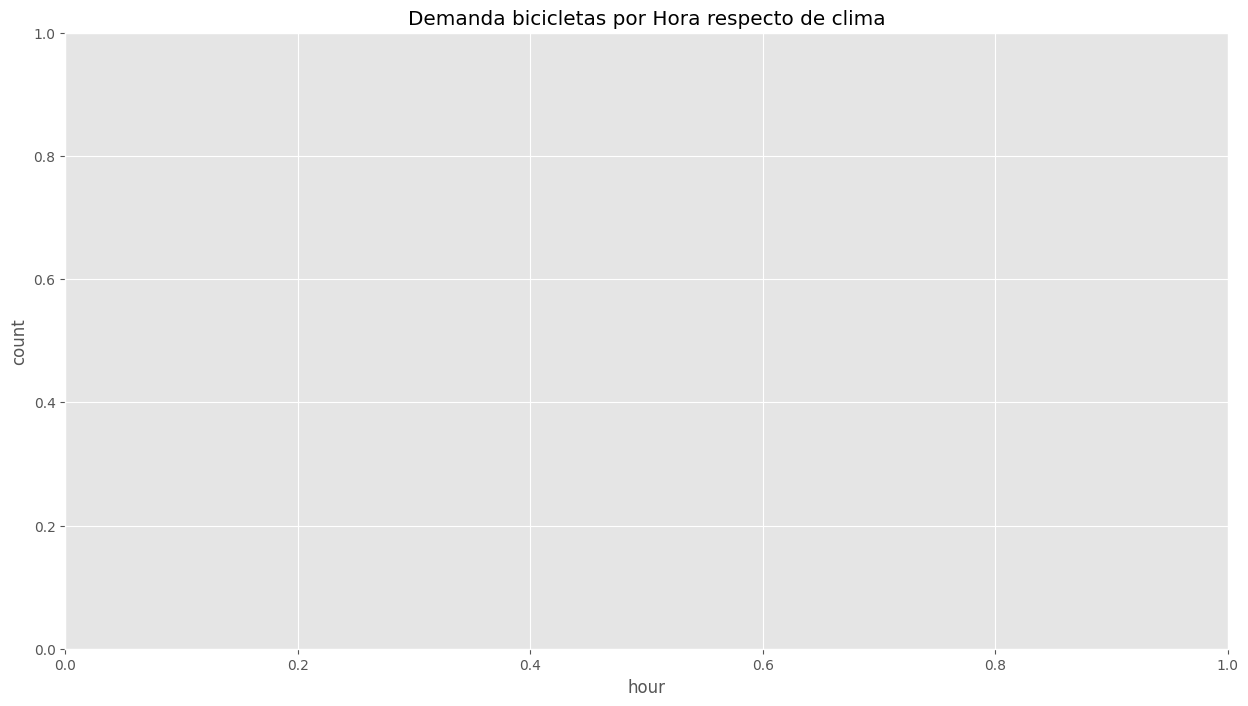

In [ ]:
# Analysing bike demand with respect to hour and different third value

# Define mappings for categorical features to text labels
month_names = {
    1: 'Enero', 2: 'Febrero', 3: 'Marzo', 4: 'Abril',
    5: 'Mayo', 6: 'Junio', 7: 'Julio', 8: 'Agosto',
    9: 'Septiembre', 10: 'Octubre', 11: 'Noviembre', 12: 'Diciembre'
}
season_labels = {
    1: 'Invierno', 2: 'Primavera', 3: 'Verano', 4: 'Otoño'
}
feriado_labels = {
    0: 'No Feriado', 1: 'Feriado'
}
clima_labels = {
    1: 'Claro', 2: 'Niebla/Nublado', 3: 'Nieve/Lluvia Ligera', 4: 'Lluvia Intensa/Granizo'
}

for i in categorical_features:
  print(i)

  if i == 'hour':
    pass
  else:
    plt.figure(figsize=(15,8))
    temp_hue_col_name = i +"_labels"
    if i == 'month':
       df[temp_hue_col_name] = df[i].map(month_names)
       print(df[temp_hue_col_name])
    elif i == 'season':
       df[temp_hue_col_name] = df[i].map(season_labels)
    elif i == 'feriado':
       df[temp_hue_col_name] = df[i].map(feriado_labels)
    elif i == 'clima':
       df[temp_hue_col_name] = df[i].map(clima_labels)
    else:
       # Fallback for any other unexpected categorical feature
       df[temp_hue_col_name] = df[i]

    sns.lineplot(x= df["hour"], y= df['count'], hue=df[temp_hue_col_name], marker ='o', palette="deep")
    plt.title(f"Demanda bicicletas por Hora respecto de {i}")
  plt.show()

## Filtering Data for 2011

To focus on the 2011 data, we'll create a new DataFrame containing only the records for `year == 0` (which represents 2011).

In [89]:
# Create a DataFrame with only 2011 data
df_2011 = df[df['year'] == 0].copy()
display(df_2011.head())

,rental_date,hour,year,month,weekday,workingday,feriado,season,temp,termic_sens,humidity,windspeed,clima,casual_usr,regist_usr,count,Nhumidity,Nwindspeed,Ntemp,Ntermic_sens
0,2011-01-01,0,0,1,6,0,0,1,9.84,14.395,81.0,0.0,1,3,13,16,0.81,0.0,0.24,0.2879
1,2011-01-01,1,0,1,6,0,0,1,9.02,13.635,80.0,0.0,1,8,32,40,0.80,0.0,0.22,0.2727
2,2011-01-01,2,0,1,6,0,0,1,9.02,13.635,80.0,0.0,1,5,27,32,0.80,0.0,0.22,0.2727
3,2011-01-01,3,0,1,6,0,0,1,9.84,14.395,75.0,0.0,1,3,10,13,0.75,0.0,0.24,0.2879
4,2011-01-01,4,0,1,6,0,0,1,9.84,14.395,75.0,0.0,1,0,1,1,0.75,0.0,0.24,0.2879


## Normalizing 'clima' (One-Hot Encoding)

The 'clima' column is a categorical feature. To use it effectively in a linear regression model, we need to convert it into a numerical format using one-hot encoding. This creates new binary columns for each category of 'clima'.

In [90]:
# One-hot encode the 'clima' column
one_hot_encoder = OneHotEncoder(sparse_output=False, drop='first') # drop='first' to avoid multicollinearity
clima_encoded = one_hot_encoder.fit_transform(df[['clima']])

# Create a DataFrame from the encoded features
clima_df = pd.DataFrame(clima_encoded, columns=one_hot_encoder.get_feature_names_out(['clima']))

# Join the new 'clima' features back to the original DataFrame
df = pd.concat([df.reset_index(drop=True), clima_df], axis=1)

# Display the head of the DataFrame with new 'clima' features
display(df.head())

,rental_date,hour,year,month,weekday,workingday,feriado,season,temp,termic_sens,...,casual_usr,regist_usr,count,Nhumidity,Nwindspeed,Ntemp,Ntermic_sens,clima_2,clima_3,clima_4
0,2011-01-01,0,0,1,6,0,0,1,9.84,14.395,...,3,13,16,0.81,0.0,0.24,0.2879,0.0,0.0,0.0
1,2011-01-01,1,0,1,6,0,0,1,9.02,13.635,...,8,32,40,0.80,0.0,0.22,0.2727,0.0,0.0,0.0
2,2011-01-01,2,0,1,6,0,0,1,9.02,13.635,...,5,27,32,0.80,0.0,0.22,0.2727,0.0,0.0,0.0
3,2011-01-01,3,0,1,6,0,0,1,9.84,14.395,...,3,10,13,0.75,0.0,0.24,0.2879,0.0,0.0,0.0
4,2011-01-01,4,0,1,6,0,0,1,9.84,14.395,...,0,1,1,0.75,0.0,0.24,0.2879,0.0,0.0,0.0


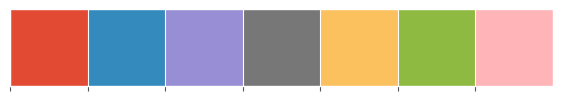

In [ ]:
# Obtener la paleta actual en uso
paleta_actual = sns.color_palette()

# Visualizar la paleta actual
sns.palplot(paleta_actual)
plt.show()